# Tutorial 00: Introduction to ML Systems

Welcome to the first tutorial in our comprehensive **ML System Design** series! This tutorial provides the foundation for understanding the difference between building ML models and building **production-ready ML systems**.

---

## About This Tutorial

| **Difficulty** | Beginner | **Time** | ~45 minutes |
|:---|:---|:---|:---|
| **Prerequisites** | Basic Python knowledge | **Type** | Conceptual + Hands-on |

---

## Learning Objectives

By the end of this tutorial, you will be able to:

1. **Understand** the difference between ML algorithms and ML systems
2. **Identify** the key components of production-ready ML systems
3. **Apply** the 7-step ML system design framework
4. **Decide** when to use ML vs traditional programming approaches
5. **Recognize** common challenges in deploying ML to production

---

## Prerequisites

Before starting this tutorial, you should:
- Have basic Python programming knowledge
- Understand what machine learning is at a high level
- Be curious about how ML works in the real world

**No prior ML experience required!** We'll explain everything step by step.

---

## Setup

Let's start by importing the necessary libraries for this tutorial.

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import math

# For visualizations
from IPython.display import display, HTML, Markdown

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11

print("Setup complete! All libraries loaded successfully.")

Setup complete! All libraries loaded successfully.


---

## 1. ML Algorithms vs ML Systems

### 1.1 What's the Difference?

When many people think about machine learning, they focus on the **algorithm** - the model that learns patterns from data. However, in real-world production environments, the algorithm is just **one small piece** of a much larger puzzle.

### Real-World Analogy: Building a House

Think of it like building a house:

| **Building a House** | **Building an ML System** |
|:---|:---|
| The furniture is what people see and use | The ML algorithm is what makes predictions |
| The entire house includes foundation, plumbing, electrical, walls... | The ML system includes data pipelines, serving infrastructure, monitoring... |
| Furniture is ~5% of building a house | ML algorithm is ~5% of building an ML system |

You wouldn't just buy furniture and call it a house, right? Similarly, you can't just train a model and call it a production ML system!

In [3]:
# Comparison: ML Algorithm vs ML System

comparison_data = {
    "Aspect": [
        "Focus",
        "Input",
        "Output",
        "Environment",
        "Main Concern",
        "Lifecycle",
        "Users",
        "Failure Impact"
    ],
    "ML Algorithm": [
        "Mathematical model that learns patterns",
        "Clean, prepared, formatted data",
        "Raw predictions (numbers, labels)",
        "Jupyter notebook, local machine",
        "Accuracy and model performance",
        "Train once, maybe retrain later",
        "Data scientists, researchers",
        "Notebook crashes, try again"
    ],
    "ML System": [
        "End-to-end solution solving business problems",
        "Raw, messy, real-world data streams",
        "Actionable results (recommendations, decisions)",
        "Production servers, cloud infrastructure",
        "Accuracy + Latency + Cost + Reliability + Scale",
        "Continuous improvement, 24/7 operation",
        "Millions of end users",
        "Revenue loss, user frustration, business impact"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("ML Algorithm vs ML System: Key Differences")
print("=" * 80)
display(comparison_df)
print("\nKey Insight: An ML algorithm is like a brain, but an ML system is the entire body!")

ML Algorithm vs ML System: Key Differences


,Aspect,ML Algorithm,ML System
0,Focus,Mathematical model that learns patterns,End-to-end solution solving business problems
1,Input,"Clean, prepared, formatted data","Raw, messy, real-world data streams"
2,Output,"Raw predictions (numbers, labels)","Actionable results (recommendations, decisions)"
3,Environment,"Jupyter notebook, local machine","Production servers, cloud infrastructure"
4,Main Concern,Accuracy and model performance,Accuracy + Latency + Cost + Reliability + Scale
5,Lifecycle,"Train once, maybe retrain later","Continuous improvement, 24/7 operation"
6,Users,"Data scientists, researchers",Millions of end users
7,Failure Impact,"Notebook crashes, try again","Revenue loss, user frustration, business impact"



Key Insight: An ML algorithm is like a brain, but an ML system is the entire body!


### 1.2 The "Tiny Box" Problem

In 2015, Google published a famous research paper called **"Hidden Technical Debt in Machine Learning Systems"**. One of its most striking findings was that the actual ML code (the algorithm) represents only a **tiny fraction** of a real-world ML system!

Let's visualize this:

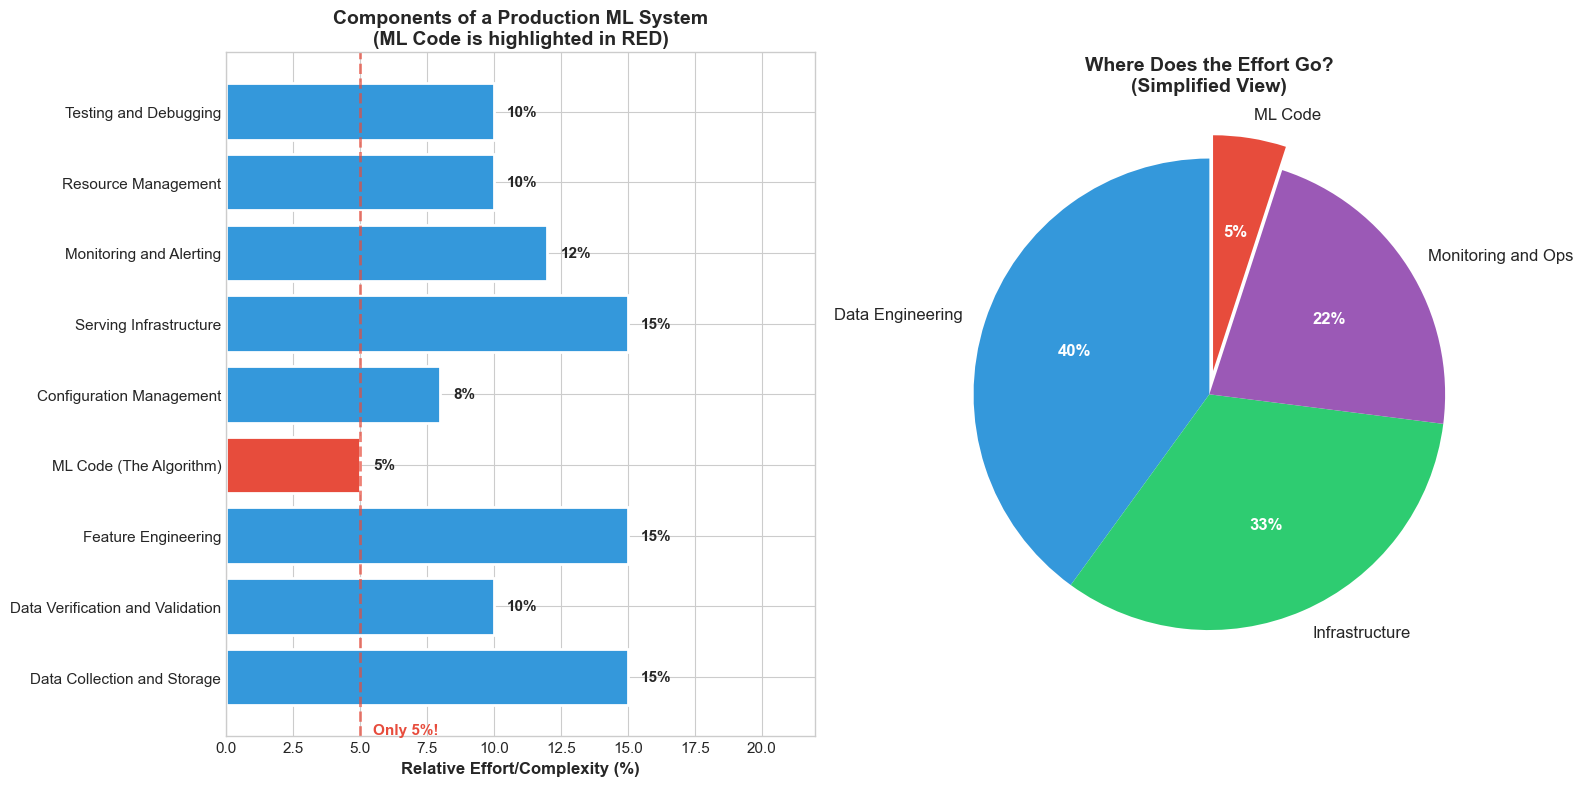


KEY INSIGHT
The actual ML algorithm is typically only ~5% of a production ML system!
The remaining 95% includes data pipelines, serving, monitoring, and more.


In [4]:
# Visualization: The "Tiny Box" - ML Code as a fraction of ML System

components = {
    'Data Collection and Storage': 15,
    'Data Verification and Validation': 10,
    'Feature Engineering': 15,
    'ML Code (The Algorithm)': 5,
    'Configuration Management': 8,
    'Serving Infrastructure': 15,
    'Monitoring and Alerting': 12,
    'Resource Management': 10,
    'Testing and Debugging': 10
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Left Plot: Horizontal Bar Chart
colors = ['#e74c3c' if 'ML Code' in k else '#3498db' for k in components.keys()]
bars = ax1.barh(list(components.keys()), list(components.values()), 
               color=colors, edgecolor='white', linewidth=2)

ax1.axvline(x=5, color='#e74c3c', linestyle='--', alpha=0.7, linewidth=2)
ax1.text(5.5, -0.8, 'Only 5%!', fontsize=11, color='#e74c3c', fontweight='bold')

for bar, value in zip(bars, components.values()):
    ax1.text(value + 0.5, bar.get_y() + bar.get_height()/2, f'{value}%', 
            va='center', fontsize=11, fontweight='bold')

ax1.set_xlabel('Relative Effort/Complexity (%)', fontsize=12, fontweight='bold')
ax1.set_title('Components of a Production ML System\n(ML Code is highlighted in RED)', 
             fontsize=14, fontweight='bold')
ax1.set_xlim(0, 22)

# Right Plot: Pie Chart
pie_data = {
    'Data Engineering': 40,
    'Infrastructure': 33,
    'Monitoring and Ops': 22,
    'ML Code': 5
}

pie_colors = ['#3498db', '#2ecc71', '#9b59b6', '#e74c3c']
explode = (0, 0, 0, 0.1)

wedges, texts, autotexts = ax2.pie(pie_data.values(), 
                                   labels=pie_data.keys(),
                                   colors=pie_colors,
                                   explode=explode,
                                   autopct='%1.0f%%',
                                   startangle=90,
                                   textprops={'fontsize': 12})

for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax2.set_title('Where Does the Effort Go?\n(Simplified View)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("KEY INSIGHT")
print("="*70)
print("The actual ML algorithm is typically only ~5% of a production ML system!")
print("The remaining 95% includes data pipelines, serving, monitoring, and more.")

### 1.3 Real-World Example: Movie Recommendation

Let's make this concrete by comparing building a recommendation **algorithm** vs a recommendation **system**.

In [6]:
# Example: Simple Recommendation Algorithm
# This is the ENTIRE "ML Code" portion - just ~5% of a production system!

from sklearn.metrics.pairwise import cosine_similarity

class SimpleRecommendationAlgorithm:
    """A simple collaborative filtering algorithm."""
    
    def __init__(self):
        self.user_item_matrix = None
        self.similarity_matrix = None
    
    def fit(self, ratings_matrix):
        """Train the model on user-item ratings."""
        self.user_item_matrix = ratings_matrix
        self.similarity_matrix = cosine_similarity(ratings_matrix.T)
        return self
    
    def predict(self, user_id, item_id):
        """Predict what rating a user would give to an item."""
        user_ratings = self.user_item_matrix[user_id]
        similarities = self.similarity_matrix[item_id]
        weighted_sum = np.dot(user_ratings, similarities)
        similarity_sum = np.sum(np.abs(similarities))
        return weighted_sum / similarity_sum if similarity_sum > 0 else 0

# Demo with sample data
np.random.seed(42)
sample_ratings = np.random.randint(0, 6, (10, 20))

algo = SimpleRecommendationAlgorithm()
algo.fit(sample_ratings)

predicted_rating = algo.predict(user_id=0, item_id=5)

print("Simple Recommendation Algorithm Demo")
print("=" * 50)
print(f"\nSample data: {sample_ratings.shape[0]} users, {sample_ratings.shape[1]} movies")
print(f"\nPrediction: User 0 would rate Movie 5 as: {predicted_rating:.2f}/5")
print("\n" + "-" * 50)
print("This is JUST the algorithm (~5% of the system!)")

Simple Recommendation Algorithm Demo

Sample data: 10 users, 20 movies

Prediction: User 0 would rate Movie 5 as: 2.96/5

--------------------------------------------------
This is JUST the algorithm (~5% of the system!)


In [7]:
# Example: Production Recommendation System Components
# This shows ALL the components needed for a real-world system.

class ProductionRecommendationSystem:
    """Conceptual outline of a production recommendation system."""
    
    def __init__(self):
        self.components = {
            'Data Ingestion': {
                'description': 'Collect user interactions in real-time',
                'technologies': ['Apache Kafka', 'AWS Kinesis', 'Spark Streaming'],
                'effort': '15%'
            },
            'Data Storage': {
                'description': 'Store raw and processed data efficiently',
                'technologies': ['PostgreSQL', 'Redis', 'Amazon S3'],
                'effort': '10%'
            },
            'Feature Engineering': {
                'description': 'Transform raw data into useful ML features',
                'technologies': ['Apache Spark', 'Feast', 'Pandas'],
                'effort': '15%'
            },
            'Model Training': {
                'description': 'Train and update recommendation models',
                'technologies': ['PyTorch', 'TensorFlow', 'MLflow'],
                'effort': '5%'
            },
            'Model Serving': {
                'description': 'Serve predictions with low latency',
                'technologies': ['TorchServe', 'FastAPI', 'Kubernetes'],
                'effort': '20%'
            },
            'Monitoring': {
                'description': 'Track system health and model performance',
                'technologies': ['Prometheus', 'Grafana', 'DataDog'],
                'effort': '15%'
            },
            'A/B Testing': {
                'description': 'Validate improvements with real users',
                'technologies': ['Optimizely', 'Custom platform'],
                'effort': '10%'
            },
            'Configuration and Ops': {
                'description': 'Manage deployment and infrastructure',
                'technologies': ['Docker', 'Kubernetes', 'Terraform'],
                'effort': '10%'
            }
        }
    
    def describe(self):
        print("PRODUCTION RECOMMENDATION SYSTEM COMPONENTS")
        print("=" * 60)
        for name, details in self.components.items():
            print(f"\n{name} ({details['effort']} of total effort)")
            print(f"   Description: {details['description']}")
            print(f"   Technologies: {', '.join(details['technologies'])}")

system = ProductionRecommendationSystem()
system.describe()

PRODUCTION RECOMMENDATION SYSTEM COMPONENTS

Data Ingestion (15% of total effort)
   Description: Collect user interactions in real-time
   Technologies: Apache Kafka, AWS Kinesis, Spark Streaming

Data Storage (10% of total effort)
   Description: Store raw and processed data efficiently
   Technologies: PostgreSQL, Redis, Amazon S3

Feature Engineering (15% of total effort)
   Description: Transform raw data into useful ML features
   Technologies: Apache Spark, Feast, Pandas

Model Training (5% of total effort)
   Description: Train and update recommendation models
   Technologies: PyTorch, TensorFlow, MLflow

Model Serving (20% of total effort)
   Description: Serve predictions with low latency
   Technologies: TorchServe, FastAPI, Kubernetes

Monitoring (15% of total effort)
   Description: Track system health and model performance
   Technologies: Prometheus, Grafana, DataDog

A/B Testing (10% of total effort)
   Description: Validate improvements with real users
   Technologies:

### Section 1 Summary

| Concept | Key Takeaway |
|:---|:---|
| **ML Algorithm** | The mathematical model that learns patterns and makes predictions |
| **ML System** | The complete end-to-end solution including data, infrastructure, and operations |
| **The 5% Rule** | ML code is typically only ~5% of a production system |
| **Why it matters** | Success in production requires skills beyond just ML algorithms |

---

## 2. Components of Production ML Systems

Now let's explore the **four major component stacks** of a production ML system:

1. **Data Stack** - Collection, processing, and storage
2. **Serving Stack** - Deploying and serving predictions
3. **Evaluation Stack** - Measuring performance
4. **Monitoring Stack** - Tracking health and detecting issues

In [ ]:
# Visualization: ML System Architecture Diagram

fig, ax = plt.subplots(figsize=(16, 12))
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.axis('off')

boxes = [
    # DATA STACK (Blue)
    {'name': 'Data\nSources', 'x': 5, 'y': 72, 'w': 16, 'h': 18, 'color': '#3498db'},
    {'name': 'Data\nProcessing', 'x': 26, 'y': 72, 'w': 16, 'h': 18, 'color': '#3498db'},
    {'name': 'Feature\nStore', 'x': 47, 'y': 72, 'w': 16, 'h': 18, 'color': '#3498db'},
    
    # MODEL STACK (Red)
    {'name': 'Model\nTraining', 'x': 26, 'y': 45, 'w': 16, 'h': 18, 'color': '#e74c3c'},
    {'name': 'Model\nRegistry', 'x': 47, 'y': 45, 'w': 16, 'h': 18, 'color': '#e74c3c'},
    
    # SERVING STACK (Green)
    {'name': 'Model\nServing', 'x': 72, 'y': 52, 'w': 18, 'h': 32, 'color': '#2ecc71'},
    
    # MONITORING STACK (Purple)
    {'name': 'Monitoring and Observability', 'x': 26, 'y': 10, 'w': 64, 'h': 20, 'color': '#9b59b6'},
    
    # USERS
    {'name': 'Users', 'x': 72, 'y': 85, 'w': 18, 'h': 10, 'color': '#f39c12'},
]

for box in boxes:
    rect = FancyBboxPatch(
        (box['x'], box['y']), box['w'], box['h'],
        boxstyle="round,pad=0.02,rounding_size=1",
        facecolor=box['color'], edgecolor='white',
        linewidth=3, alpha=0.85
    )
    ax.add_patch(rect)
    ax.text(
        box['x'] + box['w']/2, box['y'] + box['h']/2, box['name'],
        ha='center', va='center', fontsize=11, color='white', fontweight='bold'
    )

# Draw arrows
arrows = [
    ((21, 81), (26, 81)),
    ((42, 81), (47, 81)),
    ((55, 72), (42, 63)),
    ((42, 54), (47, 54)),
    ((63, 54), (72, 60)),
    ((63, 81), (72, 75)),
    ((81, 52), (81, 30)),
]

for start, end in arrows:
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=2.5))

# Stack labels
ax.text(5, 95, 'DATA STACK', fontsize=14, fontweight='bold', color='#3498db')
ax.text(5, 66, 'MODEL STACK', fontsize=14, fontweight='bold', color='#e74c3c')
ax.text(72, 48, 'SERVING', fontsize=12, fontweight='bold', color='#2ecc71')
ax.text(5, 5, 'MONITORING STACK', fontsize=12, fontweight='bold', color='#9b59b6')

ax.set_title('Production ML System Architecture', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### 2.1 The Data Stack

The **Data Stack** handles everything related to data collection, processing, and storage.

**Analogy: Data is Like Cooking Ingredients**

- **Raw data** = Fresh vegetables from the farm (dirty, unprocessed)
- **Processed data** = Washed, chopped, and prepared ingredients
- **Features** = The final mise en place, ready to cook with

In [ ]:
# Data Stack Components

data_stack = {
    "Data Sources": {
        "what_it_is": "Where your data comes from",
        "examples": [
            "User interactions (clicks, views, purchases)",
            "Content metadata (titles, descriptions)",
            "User profiles (demographics, preferences)",
            "External data (APIs, third-party data)"
        ]
    },
    "Data Processing": {
        "what_it_is": "Cleaning and transforming raw data",
        "examples": [
            "Removing duplicates and invalid records",
            "Handling missing values",
            "Joining data from different sources",
            "Aggregating data (daily totals, averages)"
        ]
    },
    "Feature Store": {
        "what_it_is": "A centralized repository for ML features",
        "examples": [
            "Reuse features across different models",
            "Ensure consistency between training and serving",
            "Track feature versions over time",
            "Serve features with low latency"
        ]
    }
}

print("DATA STACK COMPONENTS")
print("=" * 60)

for component, details in data_stack.items():
    print(f"\n{component}")
    print(f"   What it is: {details['what_it_is']}")
    print("   Examples:")
    for ex in details['examples']:
        print(f"     - {ex}")

### 2.2 The Serving Infrastructure

The **Serving Infrastructure** deploys models and serves predictions to users with low latency.

In [ ]:
# Serving Infrastructure Requirements

serving_requirements = pd.DataFrame({
    "Metric": [
        "Latency (Response Time)",
        "Throughput (Requests/sec)", 
        "Availability (Uptime)",
        "Scalability",
        "Cost Efficiency"
    ],
    "What It Means": [
        "How fast can you return a prediction?",
        "How many requests can you handle per second?",
        "What percent of time is the system working?",
        "Can you handle sudden spikes in traffic?",
        "How much does each prediction cost?"
    ],
    "Typical Target": [
        "p50 < 50ms, p99 < 200ms",
        "1,000 - 100,000 RPS",
        "99.9% - 99.99% uptime",
        "Auto-scale 2-10x in minutes",
        "$0.0001 - $0.01 per prediction"
    ]
})

print("SERVING INFRASTRUCTURE REQUIREMENTS")
print("=" * 80)
display(serving_requirements)

print("\nTERMINOLOGY:")
print("   - p50 = 50th percentile (median latency)")
print("   - p99 = 99th percentile (worst-case latency)")
print("   - RPS = Requests Per Second")

### 2.3 The Evaluation Pipeline

How do you know if your ML system is working? You need both **offline** and **online** evaluation!

In [ ]:
# Evaluation Types Comparison

evaluation_types = {
    "Offline Evaluation": {
        "when": "Before deployment",
        "metrics": ["Accuracy", "Precision/Recall", "AUC-ROC", "NDCG"],
        "data": "Historical test set",
        "pros": "Fast, cheap, reproducible",
        "cons": "May not reflect real-world performance"
    },
    "Online Evaluation": {
        "when": "During/after deployment",
        "metrics": ["Click-through rate", "Conversion rate", "Revenue", "Engagement"],
        "data": "Live user traffic",
        "pros": "Measures real impact",
        "cons": "Slow, expensive, risky"
    }
}

print("OFFLINE VS ONLINE EVALUATION")
print("=" * 60)

for eval_type, details in evaluation_types.items():
    print(f"\n{eval_type}")
    print(f"   When: {details['when']}")
    print(f"   Data: {details['data']}")
    print(f"   Metrics: {', '.join(details['metrics'])}")
    print(f"   Pros: {details['pros']}")
    print(f"   Cons: {details['cons']}")

print("\nKEY INSIGHT: You need BOTH types of evaluation!")

### 2.4 The Monitoring Stack

**Monitoring** is critical for ML systems because they can fail in subtle ways - the code works fine, but predictions become wrong!

In [ ]:
# Four Pillars of ML Monitoring

monitoring_pillars = {
    "System Metrics": {
        "question": "Is the infrastructure healthy?",
        "metrics": ["CPU/GPU utilization", "Memory usage", "Request latency", "Error rates"]
    },
    "Data Metrics": {
        "question": "Is the input data still valid?",
        "metrics": ["Feature distributions", "Missing value rates", "Data freshness", "Schema violations"]
    },
    "Model Metrics": {
        "question": "Is the model still performing?",
        "metrics": ["Prediction distribution", "Confidence scores", "Model drift", "Feature importance"]
    },
    "Business Metrics": {
        "question": "Is the system creating value?",
        "metrics": ["Click-through rate", "Conversion rate", "Revenue impact", "User engagement"]
    }
}

print("THE FOUR PILLARS OF ML MONITORING")
print("=" * 60)

for pillar, details in monitoring_pillars.items():
    print(f"\n{pillar}")
    print(f"   Question: {details['question']}")
    print("   Key Metrics:")
    for metric in details['metrics']:
        print(f"     - {metric}")

print("\nML systems need monitoring at ALL four levels!")

### Section 2 Summary

| Stack | Purpose | Key Concern |
|:---|:---|:---|
| **Data Stack** | Collect, process, and store data | Data quality and freshness |
| **Serving Stack** | Deploy models and serve predictions | Latency and reliability |
| **Evaluation Stack** | Measure offline and online performance | Model quality |
| **Monitoring Stack** | Track health and detect issues | System observability |

---

## 3. The 7-Step ML System Design Framework

This framework provides a **structured approach** to designing ML systems. Think of it as your roadmap for any ML project!

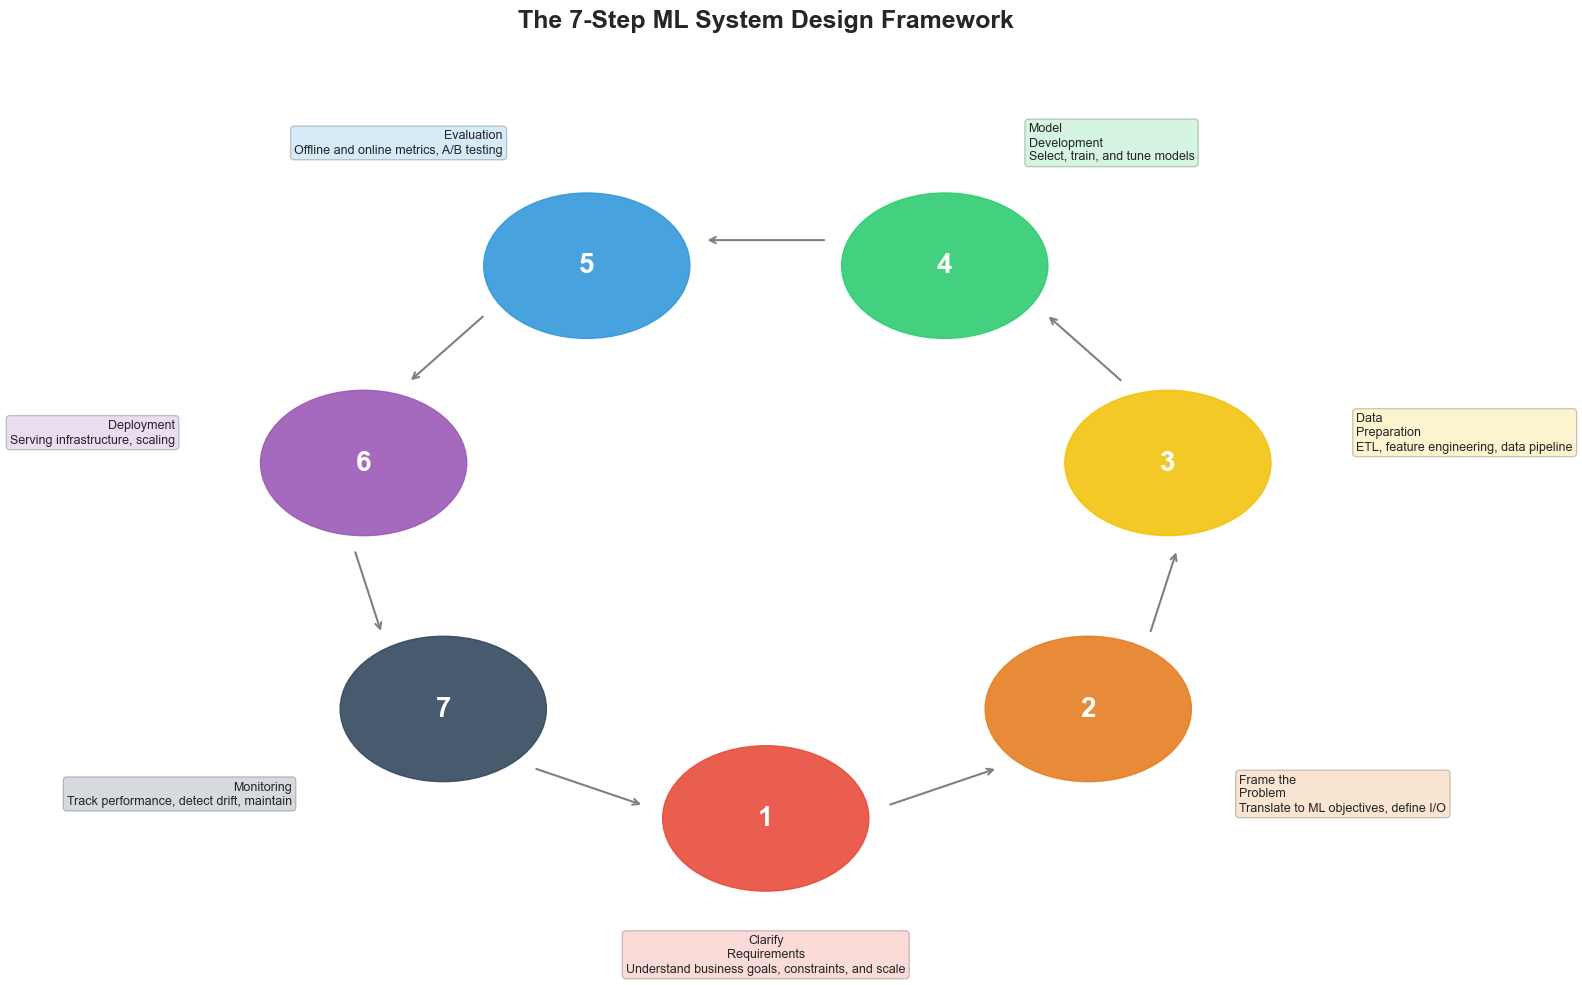

In [8]:
# Visualization: The 7-Step Framework

steps = [
    {"num": 1, "name": "Clarify\nRequirements", "color": "#e74c3c", 
     "desc": "Understand business goals, constraints, and scale"},
    {"num": 2, "name": "Frame the\nProblem", "color": "#e67e22",
     "desc": "Translate to ML objectives, define I/O"},
    {"num": 3, "name": "Data\nPreparation", "color": "#f1c40f",
     "desc": "ETL, feature engineering, data pipeline"},
    {"num": 4, "name": "Model\nDevelopment", "color": "#2ecc71",
     "desc": "Select, train, and tune models"},
    {"num": 5, "name": "Evaluation", "color": "#3498db",
     "desc": "Offline and online metrics, A/B testing"},
    {"num": 6, "name": "Deployment", "color": "#9b59b6",
     "desc": "Serving infrastructure, scaling"},
    {"num": 7, "name": "Monitoring", "color": "#34495e",
     "desc": "Track performance, detect drift, maintain"}
]

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.axis('off')

# Draw steps in a circular flow
center_x, center_y = 50, 48
radius = 32

for i, step in enumerate(steps):
    angle = (i / len(steps)) * 2 * math.pi - math.pi/2
    x = center_x + radius * math.cos(angle)
    y = center_y + radius * math.sin(angle)
    
    # Draw circle for step
    circle = plt.Circle((x, y), 8, color=step['color'], alpha=0.9)
    ax.add_patch(circle)
    
    # Add step number
    ax.text(x, y, str(step['num']), fontsize=20, fontweight='bold',
            ha='center', va='center', color='white')
    
    # Add step name and description outside
    text_x = center_x + (radius + 15) * math.cos(angle)
    text_y = center_y + (radius + 15) * math.sin(angle)
    
    ha = 'center'
    if x < center_x - 5:
        ha = 'right'
    elif x > center_x + 5:
        ha = 'left'
    
    ax.text(text_x, text_y, step['name'] + "\n" + step['desc'],
            fontsize=9, ha=ha, va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=step['color'], alpha=0.2))

# Draw arrows between steps
for i in range(len(steps)):
    angle1 = (i / len(steps)) * 2 * math.pi - math.pi/2
    angle2 = ((i + 1) / len(steps)) * 2 * math.pi - math.pi/2
    
    x1 = center_x + radius * math.cos(angle1 + 0.3)
    y1 = center_y + radius * math.sin(angle1 + 0.3)
    x2 = center_x + radius * math.cos(angle2 - 0.3)
    y2 = center_y + radius * math.sin(angle2 - 0.3)
    
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax.set_title('The 7-Step ML System Design Framework', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [9]:
# Framework Summary Table

framework_df = pd.DataFrame({
    "Step": [1, 2, 3, 4, 5, 6, 7],
    "Name": [
        "Clarify Requirements",
        "Frame the Problem",
        "Data Preparation",
        "Model Development",
        "Evaluation",
        "Deployment",
        "Monitoring"
    ],
    "Key Questions": [
        "What are we optimizing? What are the constraints?",
        "What type of ML problem is this? What are inputs/outputs?",
        "What data do we have? How do we engineer features?",
        "Which models to try? How to train them?",
        "How do we measure success? What experiments to run?",
        "How to serve predictions? How to scale?",
        "How to detect issues? When to retrain?"
    ],
    "Key Outputs": [
        "Requirements document, success metrics",
        "ML objective, I/O specification, task type",
        "ETL pipeline, feature store, dataset",
        "Trained model, hyperparameters",
        "Evaluation report, experiment results",
        "Serving infrastructure, APIs",
        "Dashboards, alerts, retraining triggers"
    ]
})

print("7-Step Framework Summary:")
print("=" * 100)
display(framework_df)

7-Step Framework Summary:


,Step,Name,Key Questions,Key Outputs
0,1,Clarify Requirements,What are we optimizing? What are the constraints?,"Requirements document, success metrics"
1,2,Frame the Problem,What type of ML problem is this? What are inpu...,"ML objective, I/O specification, task type"
2,3,Data Preparation,What data do we have? How do we engineer featu...,"ETL pipeline, feature store, dataset"
3,4,Model Development,Which models to try? How to train them?,"Trained model, hyperparameters"
4,5,Evaluation,How do we measure success? What experiments to...,"Evaluation report, experiment results"
5,6,Deployment,How to serve predictions? How to scale?,"Serving infrastructure, APIs"
6,7,Monitoring,How to detect issues? When to retrain?,"Dashboards, alerts, retraining triggers"


---

## 4. When to Use ML vs Traditional Approaches

**Not every problem needs ML!** Here's a framework to help you decide when ML is the right choice.

In [10]:
# Decision Framework: When to Use ML

def should_use_ml(problem):
    """A decision framework to determine if ML is appropriate for a problem."""
    scores = {'ml_favorable': 0, 'traditional_favorable': 0}
    reasons = []
    
    # Check: Is there a pattern to learn?
    if problem.get('has_patterns', False):
        scores['ml_favorable'] += 2
        reasons.append("+ Problem has patterns that can be learned")
    else:
        scores['traditional_favorable'] += 2
        reasons.append("- No clear patterns - rules might work better")
    
    # Check: Do you have enough data?
    data_size = problem.get('data_size', 'small')
    if data_size == 'large':
        scores['ml_favorable'] += 2
        reasons.append("+ Large dataset available for training")
    elif data_size == 'medium':
        scores['ml_favorable'] += 1
        reasons.append("~ Medium-sized dataset - might need simple models")
    else:
        scores['traditional_favorable'] += 2
        reasons.append("- Small dataset - ML may overfit")
    
    # Check: Is the problem too complex for rules?
    if problem.get('rule_complexity', 'low') == 'high':
        scores['ml_favorable'] += 2
        reasons.append("+ Too complex for hand-crafted rules")
    else:
        scores['traditional_favorable'] += 1
        reasons.append("~ Simple rules might suffice")
    
    # Check: Do you need to handle unseen cases?
    if problem.get('needs_generalization', False):
        scores['ml_favorable'] += 2
        reasons.append("+ Need to generalize to new cases")
    else:
        scores['traditional_favorable'] += 1
        reasons.append("~ Known cases can be handled with rules")
    
    # Calculate recommendation
    if scores['ml_favorable'] > scores['traditional_favorable']:
        recommendation = "ML Recommended"
    elif scores['traditional_favorable'] > scores['ml_favorable']:
        recommendation = "Traditional Approach Recommended"
    else:
        recommendation = "Consider both approaches"
    
    return recommendation, reasons

# Example problems
problems = [
    {
        'name': 'Email Spam Detection',
        'has_patterns': True,
        'data_size': 'large',
        'rule_complexity': 'high',
        'needs_generalization': True
    },
    {
        'name': 'Tax Calculation',
        'has_patterns': False,
        'data_size': 'small',
        'rule_complexity': 'low',
        'needs_generalization': False
    },
    {
        'name': 'Image Classification',
        'has_patterns': True,
        'data_size': 'large',
        'rule_complexity': 'high',
        'needs_generalization': True
    }
]

print("ML vs Traditional Approach Decision Framework")
print("=" * 60)

for problem in problems:
    print(f"\nProblem: {problem['name']}")
    recommendation, reasons = should_use_ml(problem)
    print(f"   Recommendation: {recommendation}")
    print("   Analysis:")
    for reason in reasons:
        print(f"      {reason}")

ML vs Traditional Approach Decision Framework

Problem: Email Spam Detection
   Recommendation: ML Recommended
   Analysis:
      + Problem has patterns that can be learned
      + Large dataset available for training
      + Too complex for hand-crafted rules
      + Need to generalize to new cases

Problem: Tax Calculation
   Recommendation: Traditional Approach Recommended
   Analysis:
      - No clear patterns - rules might work better
      - Small dataset - ML may overfit
      ~ Simple rules might suffice
      ~ Known cases can be handled with rules

Problem: Image Classification
   Recommendation: ML Recommended
   Analysis:
      + Problem has patterns that can be learned
      + Large dataset available for training
      + Too complex for hand-crafted rules
      + Need to generalize to new cases


In [11]:
# ML vs Traditional Decision Matrix

decision_matrix = pd.DataFrame({
    'Criteria': [
        'Pattern Complexity',
        'Data Availability',
        'Need for Generalization',
        'Rule Maintainability',
        'Interpretability Requirement',
        'Accuracy Requirement'
    ],
    'Favors ML': [
        'Complex patterns, non-linear relationships',
        'Large amounts of labeled data',
        'Must handle unseen cases',
        'Rules would be hard to maintain',
        'Black-box acceptable',
        'High accuracy critical'
    ],
    'Favors Traditional': [
        'Simple, well-defined rules',
        'Limited or no data',
        'Known, finite set of cases',
        'Rules are simple and stable',
        'Must explain every decision',
        'Good enough is sufficient'
    ]
})

print("ML vs Traditional Approach Decision Matrix:")
print("=" * 100)
display(decision_matrix)

ML vs Traditional Approach Decision Matrix:


,Criteria,Favors ML,Favors Traditional
0,Pattern Complexity,"Complex patterns, non-linear relationships","Simple, well-defined rules"
1,Data Availability,Large amounts of labeled data,Limited or no data
2,Need for Generalization,Must handle unseen cases,"Known, finite set of cases"
3,Rule Maintainability,Rules would be hard to maintain,Rules are simple and stable
4,Interpretability Requirement,Black-box acceptable,Must explain every decision
5,Accuracy Requirement,High accuracy critical,Good enough is sufficient


---

## 5. Hands-On Exercise: Analyze a Recommendation System

Let's apply what we've learned by analyzing the architecture of a movie recommendation system.

In [12]:
# Exercise: Map a Recommendation System to the 7-Step Framework

class MLSystemAnalysis:
    """Analyze an ML system using the 7-step framework."""
    
    def __init__(self, name):
        self.name = name
        self.steps = {}
    
    def add_step(self, step_num, step_name, details):
        self.steps[step_num] = {'name': step_name, 'details': details}
    
    def display_analysis(self):
        print(f"\nSystem Analysis: {self.name}")
        print("=" * 60)
        for step_num in sorted(self.steps.keys()):
            step = self.steps[step_num]
            print(f"\nStep {step_num}: {step['name']}")
            print("-" * 40)
            for key, value in step['details'].items():
                print(f"  - {key}: {value}")

# Create analysis for Netflix-like recommendation system
netflix = MLSystemAnalysis("Netflix-like Movie Recommendations")

netflix.add_step(1, "Clarify Requirements", {
    "Business Goal": "Increase user engagement and retention",
    "Success Metric": "Time spent watching / Subscriber retention",
    "Scale": "200M+ users, 15K+ titles",
    "Latency Requirement": "< 200ms for recommendations"
})

netflix.add_step(2, "Frame the Problem", {
    "ML Objective": "Predict user engagement score for each movie",
    "Input": "User features + Movie features + Context",
    "Output": "Ranked list of movies",
    "Task Type": "Learning-to-Rank / Regression"
})

netflix.add_step(3, "Data Preparation", {
    "Data Sources": "Watch history, ratings, search queries",
    "Features": "User embeddings, movie embeddings, temporal",
    "Data Pipeline": "Streaming ingestion + Batch processing"
})

netflix.add_step(4, "Model Development", {
    "Model Architecture": "Two-tower neural network",
    "Training Frequency": "Daily batch + Real-time updates",
    "Candidate Generation": "Approximate nearest neighbor search"
})

netflix.add_step(5, "Evaluation", {
    "Offline Metrics": "Recall@K, NDCG, Hit Rate",
    "Online Metrics": "CTR, Watch Time, Retention",
    "Testing": "A/B testing with holdout groups"
})

netflix.add_step(6, "Deployment", {
    "Serving Strategy": "Two-stage: Candidate retrieval + Ranking",
    "Infrastructure": "Distributed model serving",
    "Caching": "Pre-computed candidates for cold start"
})

netflix.add_step(7, "Monitoring", {
    "System Metrics": "Latency, throughput, error rates",
    "Model Metrics": "Prediction distribution, feature drift",
    "Business Metrics": "Daily active users, engagement trends"
})

netflix.display_analysis()


System Analysis: Netflix-like Movie Recommendations

Step 1: Clarify Requirements
----------------------------------------
  - Business Goal: Increase user engagement and retention
  - Success Metric: Time spent watching / Subscriber retention
  - Scale: 200M+ users, 15K+ titles
  - Latency Requirement: < 200ms for recommendations

Step 2: Frame the Problem
----------------------------------------
  - ML Objective: Predict user engagement score for each movie
  - Input: User features + Movie features + Context
  - Output: Ranked list of movies
  - Task Type: Learning-to-Rank / Regression

Step 3: Data Preparation
----------------------------------------
  - Data Sources: Watch history, ratings, search queries
  - Features: User embeddings, movie embeddings, temporal
  - Data Pipeline: Streaming ingestion + Batch processing

Step 4: Model Development
----------------------------------------
  - Model Architecture: Two-tower neural network
  - Training Frequency: Daily batch + Real-time

### Try It Yourself!

Now it's your turn! Create an analysis for one of these systems:
- Fraud Detection System (for a bank)
- Search Ranking System (for e-commerce)
- Content Moderation System (for social media)

In [ ]:
# TODO: Create your own ML system analysis
# Uncomment and complete the code below:

# your_system = MLSystemAnalysis("Your System Name")

# your_system.add_step(1, "Clarify Requirements", {
#     "Business Goal": "...",
#     "Success Metric": "...",
#     "Scale": "...",
#     "Latency Requirement": "...",
# })

# Add steps 2-7...

# your_system.display_analysis()

print("Tip: Think about what makes each system unique in terms of:")
print("   - What data is available?")
print("   - What are the latency constraints?")
print("   - What happens if the model is wrong?")
print("   - How do you measure success?")

---

## Summary

### Key Takeaways

1. **ML Algorithm is not equal to ML System**: The algorithm is just ~5% of a production ML system. The rest includes data pipelines, serving infrastructure, monitoring, and more.

2. **Four Main Components** of production ML systems:
   - **Data Stack**: Collection, processing, and storage
   - **Serving Infrastructure**: Low-latency predictions at scale
   - **Evaluation Pipeline**: Offline and online metrics
   - **Monitoring Systems**: Track health and detect issues

3. **The 7-Step Framework** provides a systematic approach:
   1. Clarify Requirements
   2. Frame the Problem
   3. Data Preparation
   4. Model Development
   5. Evaluation
   6. Deployment
   7. Monitoring

4. **ML is not always the answer**: Consider traditional approaches when:
   - Data is scarce
   - Rules are simple and well-defined
   - Interpretability is critical
   - The problem is deterministic

### What's Next?

In the next tutorial, we'll dive deep into **Step 1: Clarifying Requirements** - learning how to ask the right questions to understand business objectives, constraints, and scale requirements.

---

## Additional Resources

- [Hidden Technical Debt in Machine Learning Systems](https://papers.nips.cc/paper/2015/file/86df7dcfd896fcaf2674f757a2463eba-Paper.pdf) - Google's seminal paper
- [Machine Learning System Design Interview](https://www.amazon.com/Machine-Learning-System-Design-Interview/dp/1736049127) - Book reference
- [Made With ML](https://madewithml.com/) - Practical MLOps course

In [ ]:
# Final Review: Quick Self-Assessment Quiz

quiz_questions = [
    {
        "question": "What percentage of a production ML system is typically the ML algorithm itself?",
        "options": ["A) 50%", "B) 25%", "C) 5%", "D) 80%"],
        "answer": "C"
    },
    {
        "question": "Which component is responsible for serving predictions with low latency?",
        "options": ["A) Data Stack", "B) Serving Infrastructure", "C) Evaluation Pipeline", "D) Feature Store"],
        "answer": "B"
    },
    {
        "question": "When should you prefer traditional approaches over ML?",
        "options": ["A) When you have lots of data", "B) When patterns are complex", 
                   "C) When rules are simple and well-defined", "D) When you need generalization"],
        "answer": "C"
    }
]

print("Quick Self-Assessment Quiz")
print("=" * 50)

for i, q in enumerate(quiz_questions, 1):
    print(f"\nQ{i}: {q['question']}")
    for opt in q['options']:
        print(f"   {opt}")

print("\n" + "=" * 50)
print("Answers: 1-C, 2-B, 3-C")